# Chapter 2

In [4]:
library(survival)
library(dplyr)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




In [5]:
df <- read.csv("./data/veteran.csv")
head(df)

,ID,TIME,Y,trt,celltype,karno,diagtime,age,priortherapy
,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<chr>
1,1,0,0,standard,squamous,60,7,69,no
2,1,72,1,standard,squamous,60,7,69,no
3,2,0,0,standard,squamous,70,5,64,yes
4,2,411,1,standard,squamous,70,5,64,yes
5,3,0,0,standard,squamous,60,3,38,no
6,3,228,1,standard,squamous,60,3,38,no


Kaplan-Meier曲線

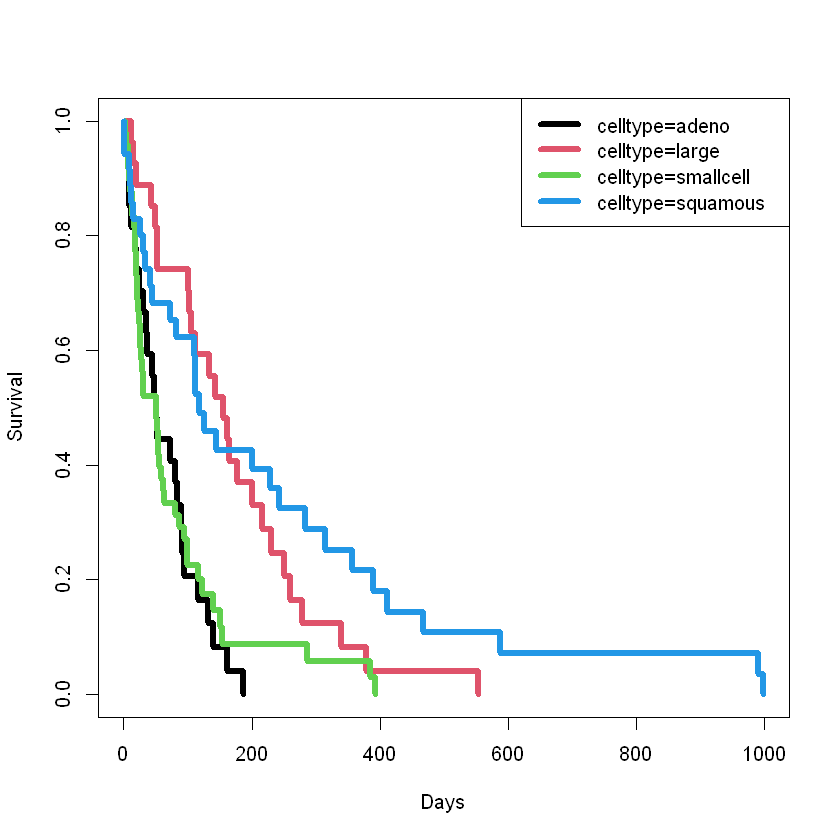

In [6]:
surv = survfit(Surv(TIME, Y) ~ celltype, data = df)
plot(surv, lwd = 5, col = 1:4, xlab = "Days", ylab = "Survival")
legend("topright", legend=names(surv$strata), lwd = 5, col = 1:4)

ログランク検定

In [7]:
survdiff(Surv(TIME, Y) ~ celltype, data = df)

Call:
survdiff(formula = Surv(TIME, Y) ~ celltype, data = df)

                    N Observed Expected (O-E)^2/E (O-E)^2/V
celltype=adeno     54       26     15.7      6.77      8.19
celltype=large     54       26     34.5      2.12      3.02
celltype=smallcell 96       45     30.1      7.37     10.20
celltype=squamous  70       31     47.7      5.82     10.53

 Chisq= 25.4  on 3 degrees of freedom, p= 1e-05 

In [8]:
df <- read.csv("./data/addicts.csv")
head(df)

,id,clinic,status,survt,prison,dose
,<int>,<int>,<int>,<int>,<int>,<int>
1,1,1,1,428,0,50
2,2,1,1,275,1,55
3,3,1,1,262,0,55
4,4,1,1,183,0,30
5,5,1,1,259,1,65
6,6,1,1,714,0,55


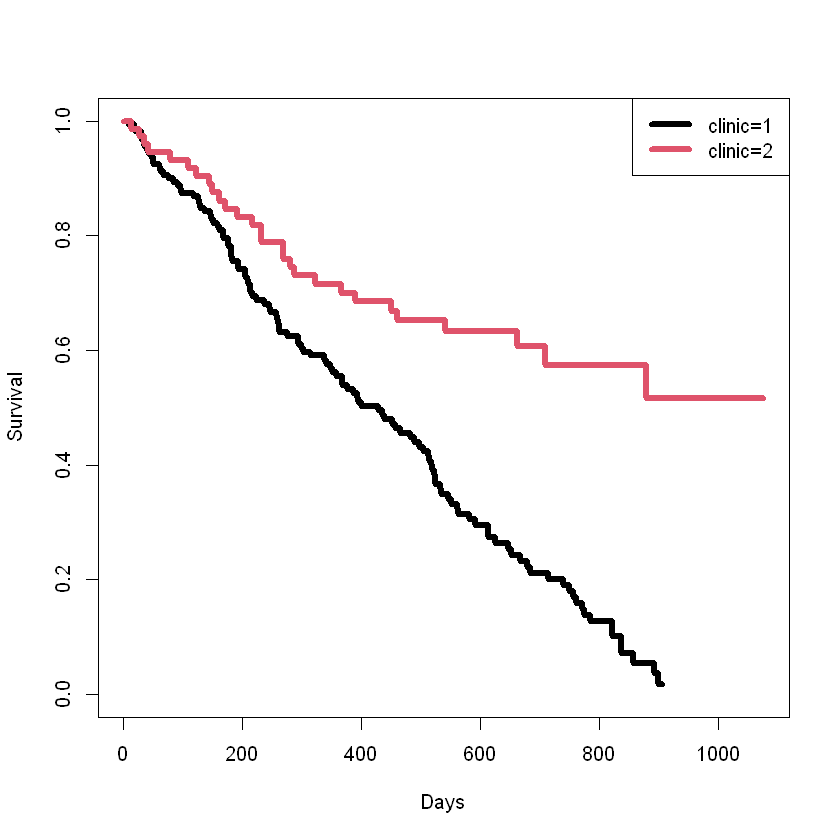

In [9]:
surv = survfit(Surv(survt, status) ~ clinic, data = df)
plot(surv, lwd = 5, col = 1:2, xlab = "Days", ylab = "Survival")
legend("topright", legend=names(surv$strata), lwd = 5, col = 1:2)

In [10]:
survdiff(Surv(survt, status) ~ clinic, data = df)

Call:
survdiff(formula = Surv(survt, status) ~ clinic, data = df)

           N Observed Expected (O-E)^2/E (O-E)^2/V
clinic=1 163      122     90.9      10.6      27.9
clinic=2  75       28     59.1      16.4      27.9

 Chisq= 27.9  on 1 degrees of freedom, p= 1e-07 

Wilcoxon検定

In [11]:
survdiff(Surv(survt, status) ~ clinic, rho = 1, data = df)

Call:
survdiff(formula = Surv(survt, status) ~ clinic, data = df, rho = 1)

           N Observed Expected (O-E)^2/E (O-E)^2/V
clinic=1 163     77.3     61.4      4.08      15.8
clinic=2  75     19.9     35.7      7.03      15.8

 Chisq= 15.8  on 1 degrees of freedom, p= 7e-05 

high (70+), medium (55–70), low (<55)で層別化

In [12]:
df <- df %>%
  mutate(dose_cat = case_when(
    dose >= 70 ~ "high",
    dose >= 55 ~ "medium",
    TRUE ~ "low"
  ))

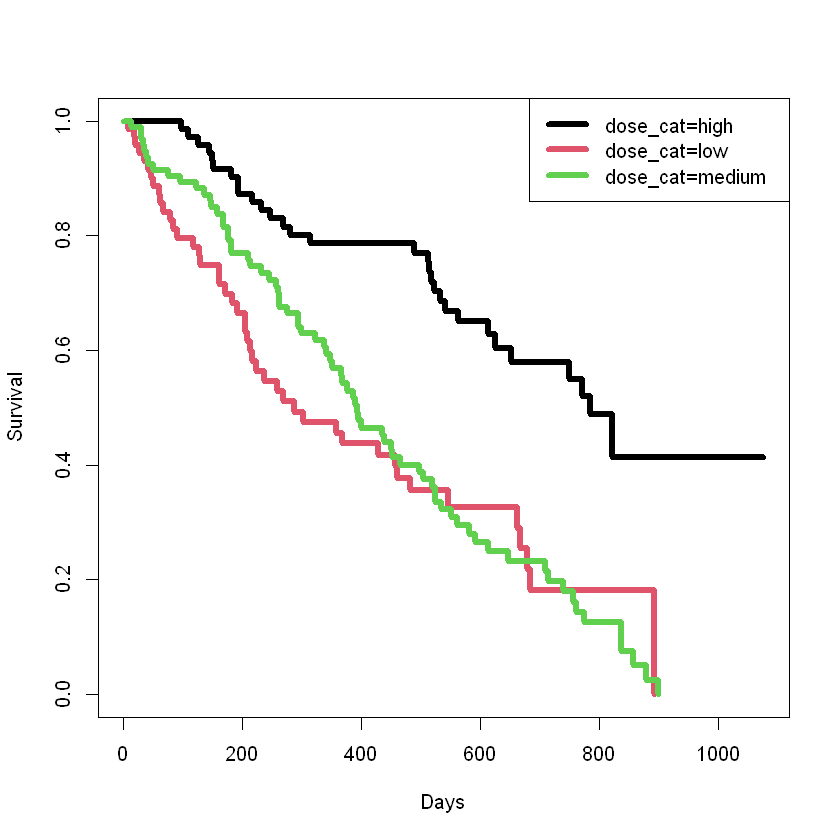

In [13]:
surv = survfit(Surv(survt, status) ~ dose_cat, data = df)
plot(surv, lwd = 5, col = 1:3, xlab = "Days", ylab = "Survival")
legend("topright", legend=names(surv$strata), lwd = 5, col = 1:3)

In [14]:
survdiff(Surv(survt, status) ~ dose_cat, data = df)

Call:
survdiff(formula = Surv(survt, status) ~ dose_cat, data = df)

                 N Observed Expected (O-E)^2/E (O-E)^2/V
dose_cat=high   71       31     65.0     17.77     32.84
dose_cat=low    72       45     30.9      6.40      8.21
dose_cat=medium 95       74     54.1      7.33     11.65

 Chisq= 33  on 2 degrees of freedom, p= 7e-08 